# 01. Análise Exploratória (EDA)
## Predição de Alfabetização, Tech Challenge Fase 3

**Objetivo desta análise:** entender o comportamento dos dados da base de modelagem
(`gold_base_ml_alunos`, grão aluno, 2023-2024), identificar padrões, avaliar
distribuições, detectar correlações e formular as **hipóteses analíticas** que
sustentam as decisões de modelagem do notebook 02.

A base foi construída na camada Gold da Fase 2 e enriquecida com Censo Escolar,
IBGE, Atlas do Desenvolvimento Humano e IDEB (detalhes e decisões anti-leakage em
`reports/base_analitica.md`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
IMG = Path("../images")
IMG.mkdir(exist_ok=True)

df = pd.read_parquet("../data/gold_base_ml_alunos.parquet")
print(df.shape)
df.head()

(3355846, 39)


,ano,id_municipio,id_escola,peso_aluno,alfabetizado,rede,alunos_avaliados_escola,regiao,sigla_uf,n_escolas_anos_iniciais,...,renda_pc,prop_pobreza,prop_pobreza_criancas,taxa_analfabetismo_15_mais,taxa_criancas_fora_escola_6_14,expectativa_anos_estudo,taxa_agua_encanada,ideb_ai_publica_anterior,taxa_aprovacao_ai_anterior,nota_saeb_lp_ai_anterior
0,2024,1100114,60000288,1.090000,True,Municipal,66,Norte,RO,19,...,575.14,13.78,21.51,10.66,2.23,9.42,97.09,5.9,99.8,207.89
1,2024,1100122,60000272,1.210000,False,Municipal,154,Norte,RO,58,...,743.35,8.56,14.72,7.79,3.44,9.95,97.81,5.9,98.4,207.53
2,2023,1100155,60000122,1.255046,False,Municipal,16,Norte,RO,13,...,576.51,11.73,19.31,10.36,3.91,9.17,97.80,5.4,99.5,196.45
3,2023,1100205,60000345,1.365476,False,Municipal,88,Norte,RO,182,...,929.19,7.95,13.61,5.10,5.48,8.99,92.87,5.4,99.2,197.55
4,2024,1100205,60000358,1.050000,True,Municipal,38,Norte,RO,178,...,929.19,7.95,13.61,5.10,5.48,8.99,92.87,5.4,96.4,201.50


## 1. Visão geral

Estrutura, tipos e completude da base.

In [2]:
resumo = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos_%": (df.isna().mean() * 100).round(2),
    "n_unicos": df.nunique(),
})
resumo

,tipo,nulos_%,n_unicos
ano,Int64,0.00,2
id_municipio,str,0.00,5547
id_escola,str,0.00,42802
peso_aluno,float64,0.04,70528
alfabetizado,boolean,0.00,2
rede,str,0.00,3
alunos_avaliados_escola,Int64,0.00,277
regiao,str,0.00,5
sigla_uf,str,0.00,26
n_escolas_anos_iniciais,Int64,0.00,231


## 2. O alvo: `alfabetizado`

Balanceamento geral e por ano. As taxas oficiais do programa são ponderadas pelo
peso amostral (`peso_aluno`); mostramos as duas visões.

Distribuição simples:
alfabetizado
True     0.5914
False    0.4086
Name: proportion, dtype: Float64

Taxa de alfabetização (ponderada pelo peso amostral):
ano
2023    0.5746
2024    0.5920
dtype: float64


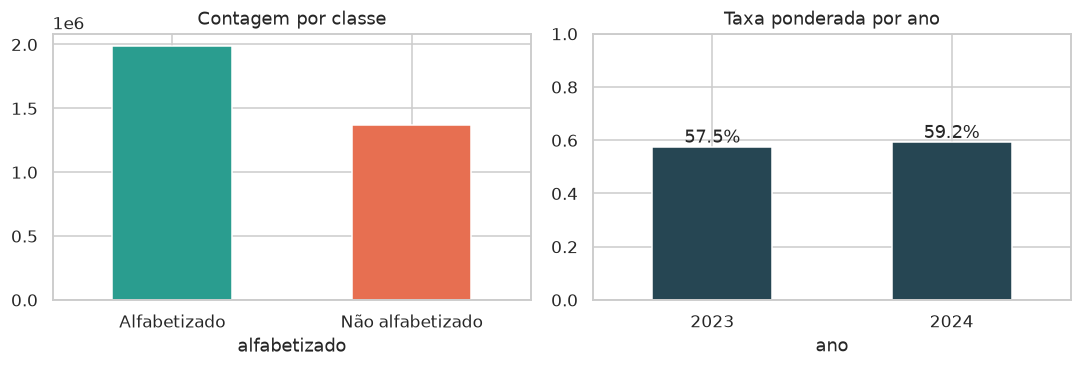

In [3]:
def taxa_ponderada(g):
    # 1.185 alunos (0,04%) chegam sem peso amostral; ficam fora da média ponderada
    g = g.dropna(subset=["peso_aluno"])
    return np.average(g["alfabetizado"], weights=g["peso_aluno"])

print("Distribuição simples:")
print(df["alfabetizado"].value_counts(normalize=True).round(4))

print("\nTaxa de alfabetização (ponderada pelo peso amostral):")
print(df.groupby("ano")[["alfabetizado", "peso_aluno"]]
        .apply(taxa_ponderada).round(4))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
df["alfabetizado"].value_counts().plot.bar(ax=ax[0], color=["#2a9d8f", "#e76f51"], rot=0)
ax[0].set_title("Contagem por classe")
ax[0].set_xticklabels(["Alfabetizado", "Não alfabetizado"])
por_ano = df.groupby("ano")[["alfabetizado", "peso_aluno"]].apply(taxa_ponderada)
por_ano.plot.bar(ax=ax[1], color="#264653", rot=0)
ax[1].set_title("Taxa ponderada por ano")
ax[1].set_ylim(0, 1)
for p in ax[1].patches:
    ax[1].annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width()/2, p.get_height()),
                   ha="center", va="bottom")
plt.tight_layout()
plt.savefig(IMG / "eda_alvo.png", bbox_inches="tight")
plt.show()

**Leitura:** o problema é razoavelmente balanceado (≈59% × 41%), o que dispensa
técnicas agressivas de reamostragem; a taxa nacional subiu de 2023 para 2024,
compatível com a divulgação oficial do programa.

## 3. Recortes estruturais: rede, região e UF

Onde a alfabetização está mais alta e mais baixa?

**Dois fatos de cobertura que a base revela** (e que o modelo precisa respeitar):

1. A avaliação cobre essencialmente a **rede pública**: 2,98 mi de alunos
   municipais e 373 mil estaduais; a rede privada aparece com só **24 alunos**
   (casos residuais/conveniados) e a federal não aparece. Ou seja, `rede` no
   modelo compara **municipal × estadual**, e nada além disso.
2. **Roraima (RR) não está na base** em nenhum dos dois anos: o estado não tem
   dados divulgados no indicador. Conclusões nacionais valem para 26 UFs + DF.

rede
Municipal    2983123
Estadual      372699
Privada           24

UFs presentes por ano:
ano
2023    23
2024    26


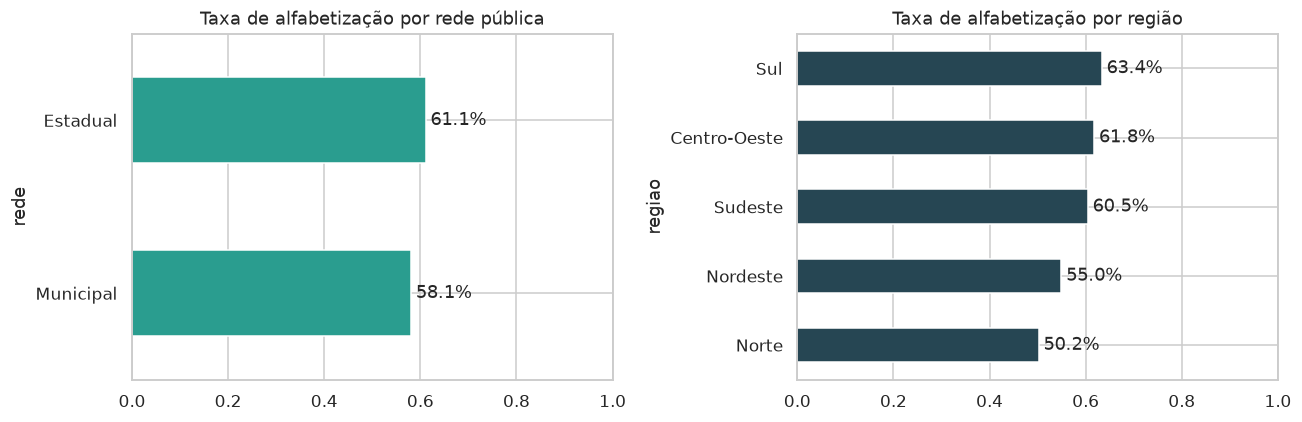

In [4]:
print(df["rede"].value_counts().to_string())
print("\nUFs presentes por ano:")
print(df.groupby("ano")["sigla_uf"].nunique().to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
publicas = df[df["rede"].isin(["Municipal", "Estadual"])]
por_rede = (publicas.groupby("rede")[["alfabetizado", "peso_aluno"]]
              .apply(taxa_ponderada).sort_values())
por_rede.plot.barh(ax=ax[0], color="#2a9d8f")
ax[0].set_title("Taxa de alfabetização por rede pública")
ax[0].set_xlim(0, 1)
for i, v in enumerate(por_rede):
    ax[0].text(v + 0.01, i, f"{v:.1%}", va="center")

por_regiao = (df.groupby("regiao")[["alfabetizado", "peso_aluno"]]
                .apply(taxa_ponderada).sort_values())
por_regiao.plot.barh(ax=ax[1], color="#264653")
ax[1].set_title("Taxa de alfabetização por região")
ax[1].set_xlim(0, 1)
for i, v in enumerate(por_regiao):
    ax[1].text(v + 0.01, i, f"{v:.1%}", va="center")
plt.tight_layout()
plt.savefig(IMG / "eda_rede_regiao.png", bbox_inches="tight")
plt.show()

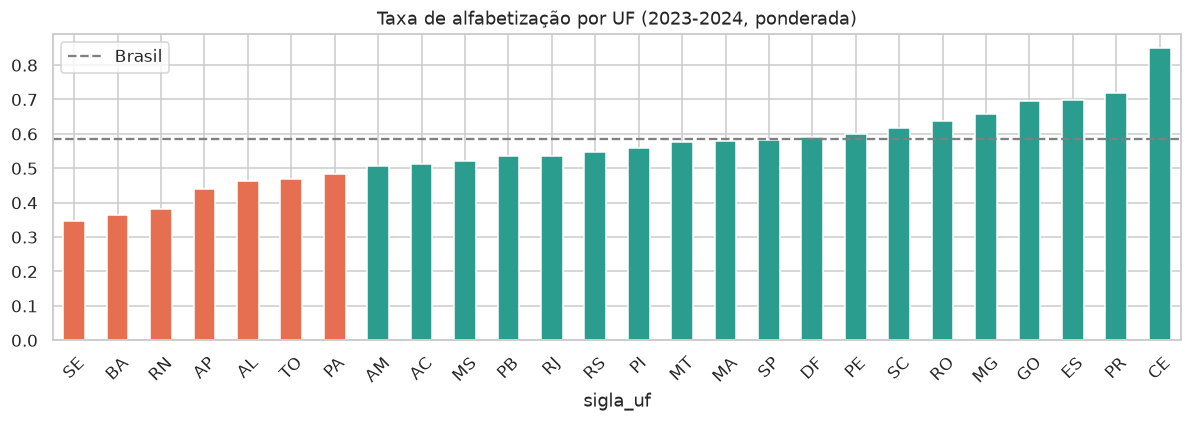

sigla_uf
SE    0.347
BA    0.364
RN    0.382
AP    0.441
AL    0.462
TO    0.469
PA    0.483
AM    0.507
AC    0.514
MS    0.520
PB    0.534
RJ    0.536
RS    0.546
PI    0.560
MT    0.577
MA    0.580
SP    0.581
DF    0.591
PE    0.598
SC    0.617
RO    0.636
MG    0.658
GO    0.696
ES    0.698
PR    0.718
CE    0.849
dtype: float64

In [5]:
por_uf = (df.groupby("sigla_uf")[["alfabetizado", "peso_aluno"]]
            .apply(taxa_ponderada).sort_values())
fig, ax = plt.subplots(figsize=(11, 4))
cores = ["#e76f51" if v < 0.5 else "#2a9d8f" for v in por_uf]
por_uf.plot.bar(ax=ax, color=cores, rot=45)
ax.axhline(taxa_ponderada(df), ls="--", color="gray", label="Brasil")
ax.set_title("Taxa de alfabetização por UF (2023-2024, ponderada)")
ax.legend()
plt.tight_layout()
plt.savefig(IMG / "eda_uf.png", bbox_inches="tight")
plt.show()
por_uf.round(3)

**Leitura:** o gradiente territorial é forte. Norte e Nordeste concentram as
menores taxas (algumas UFs abaixo de 50%), Sul e Sudeste as maiores. Território
e rede precisam estar no modelo.

## 4. Contexto socioeconômico municipal × alfabetização

Relação entre o desfecho individual e as condições do município (IDHM, renda,
pobreza, IDEB anterior). Para não misturar grãos, agregamos primeiro no nível
municipal (taxa ponderada por município/ano) e cruzamos com as features.

In [6]:
feat_municipais = [
    "idhm", "idhm_e", "idhm_l", "idhm_r", "indice_gini", "renda_pc",
    "prop_pobreza", "prop_pobreza_criancas", "taxa_analfabetismo_15_mais",
    "taxa_criancas_fora_escola_6_14", "expectativa_anos_estudo", "taxa_agua_encanada",
    "pib_per_capita_ano_anterior", "populacao",
    "ideb_ai_publica_anterior", "taxa_aprovacao_ai_anterior", "nota_saeb_lp_ai_anterior",
    "n_escolas_anos_iniciais", "pct_escolas_urbanas", "pct_biblioteca_ou_sala_leitura",
    "pct_internet", "pct_internet_alunos", "pct_lab_informatica", "pct_agua_potavel",
    "pct_esgoto_rede_publica", "pct_energia_rede_publica", "pct_quadra_esportes",
    "pct_alimentacao", "media_matriculas_ai_por_escola", "pct_equipamento_computador",
]

mun = (df.groupby(["ano", "id_municipio"])
         .apply(lambda g: pd.Series({
             "taxa_alfabetizacao": taxa_ponderada(g),
             "n_alunos": len(g),
             **{f: g[f].iloc[0] for f in feat_municipais},
         }))
         .reset_index())
print(mun.shape)
mun.head(3)

(10388, 34)


,ano,id_municipio,taxa_alfabetizacao,n_alunos,idhm,idhm_e,idhm_l,idhm_r,indice_gini,renda_pc,...,pct_internet,pct_internet_alunos,pct_lab_informatica,pct_agua_potavel,pct_esgoto_rede_publica,pct_energia_rede_publica,pct_quadra_esportes,pct_alimentacao,media_matriculas_ai_por_escola,pct_equipamento_computador
0,2023,1100015,0.645472,227.0,0.641,0.526,0.763,0.657,0.58,476.99,...,0.8,0.200000,0.050000,1.000000,0.000000,0.75,0.55,1.000000,75.500000,0.6
1,2023,1100023,0.622982,1222.0,0.702,0.600,0.806,0.716,0.53,689.95,...,1.0,0.642857,0.821429,0.964286,0.035714,1.00,0.75,0.821429,249.392857,1.0
2,2023,1100031,0.690995,76.0,0.650,0.559,0.757,0.650,0.51,457.17,...,1.0,0.000000,0.333333,1.000000,0.000000,1.00,1.00,1.000000,122.666667,1.0


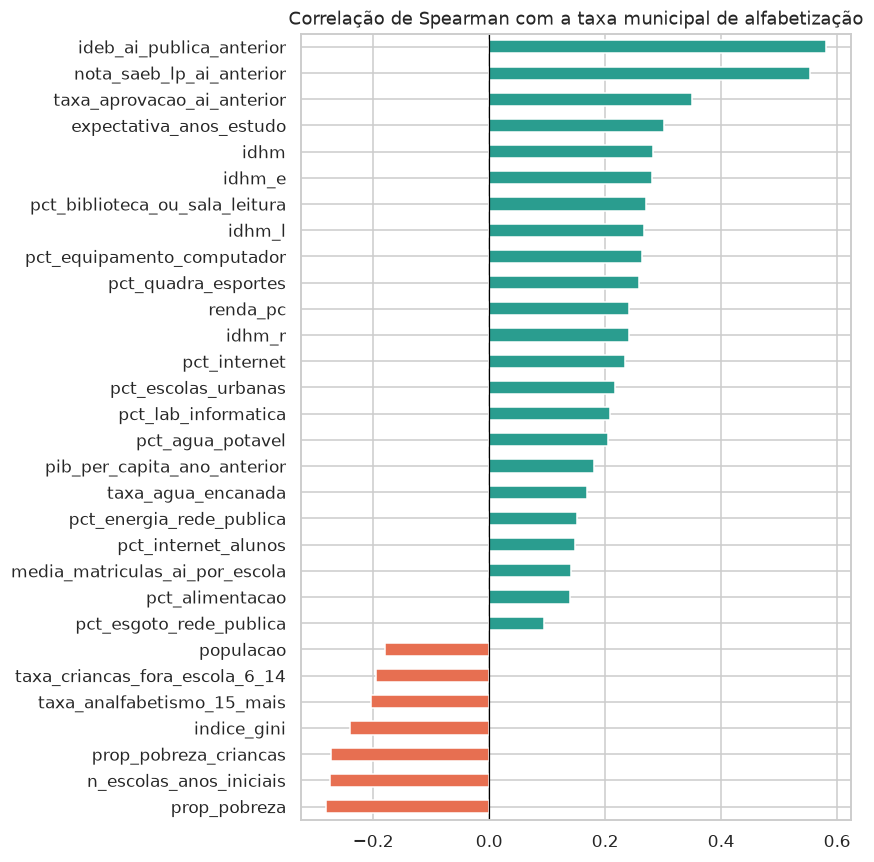

prop_pobreza                     -0.282
n_escolas_anos_iniciais          -0.275
prop_pobreza_criancas            -0.272
indice_gini                      -0.239
taxa_analfabetismo_15_mais       -0.205
taxa_criancas_fora_escola_6_14   -0.196
populacao                        -0.180
pct_esgoto_rede_publica           0.095
pct_alimentacao                   0.140
media_matriculas_ai_por_escola    0.141
pct_internet_alunos               0.148
pct_energia_rede_publica          0.152
taxa_agua_encanada                0.168
pib_per_capita_ano_anterior       0.181
pct_agua_potavel                  0.206
pct_lab_informatica               0.208
pct_escolas_urbanas               0.217
pct_internet                      0.234
idhm_r                            0.242
renda_pc                          0.242
pct_quadra_esportes               0.259
pct_equipamento_computador        0.264
idhm_l                            0.266
pct_biblioteca_ou_sala_leitura    0.271
idhm_e                            0.281


In [7]:
corr = (mun[["taxa_alfabetizacao"] + feat_municipais]
        .corr(method="spearman")["taxa_alfabetizacao"]
        .drop("taxa_alfabetizacao")
        .sort_values())
fig, ax = plt.subplots(figsize=(8, 8))
corr.plot.barh(ax=ax, color=["#e76f51" if v < 0 else "#2a9d8f" for v in corr])
ax.set_title("Correlação de Spearman com a taxa municipal de alfabetização")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.savefig(IMG / "eda_correlacoes.png", bbox_inches="tight")
plt.show()
corr.round(3)

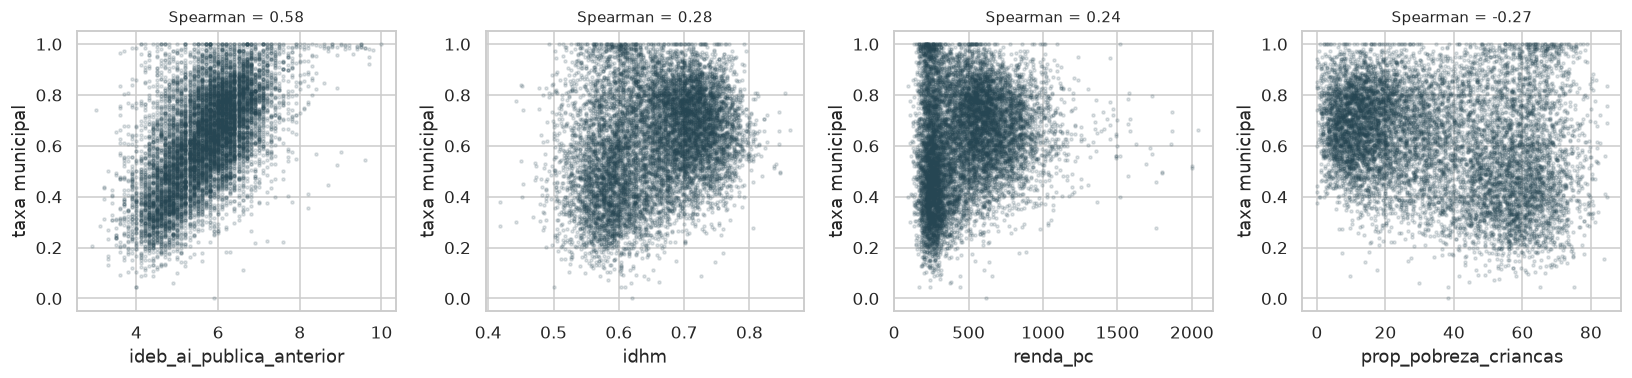

In [8]:
top = ["ideb_ai_publica_anterior", "idhm", "renda_pc", "prop_pobreza_criancas"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, f in zip(axes, top):
    ax.scatter(mun[f], mun["taxa_alfabetizacao"], s=4, alpha=0.15, color="#264653")
    ax.set_xlabel(f)
    ax.set_ylabel("taxa municipal")
    ax.set_title(f"Spearman = {mun[[f, 'taxa_alfabetizacao']].corr(method='spearman').iloc[0,1]:.2f}",
                 fontsize=10)
plt.tight_layout()
plt.savefig(IMG / "eda_dispersao_top.png", bbox_inches="tight")
plt.show()

**Leitura:** o histórico educacional do município (IDEB/nota Saeb da edição
anterior) e o bloco socioeconômico (IDHM, renda, pobreza, com sinal invertido)
carregam as maiores correlações. A infraestrutura escolar correlaciona de forma
moderada e na direção esperada.

## 5. Desigualdade: quintis de IDHM e urbano × rural

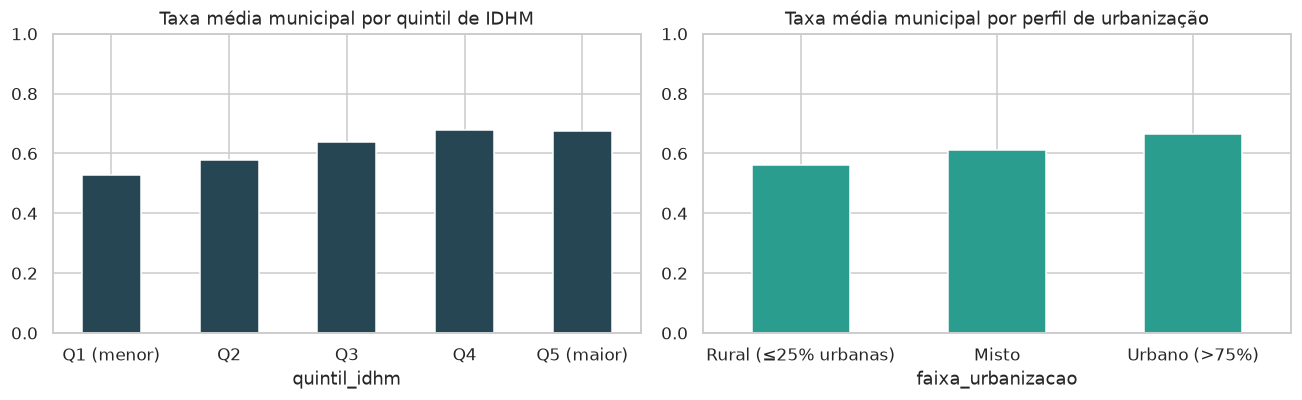

In [9]:
mun["quintil_idhm"] = pd.qcut(mun["idhm"], 5, labels=["Q1 (menor)", "Q2", "Q3", "Q4", "Q5 (maior)"])
mun["faixa_urbanizacao"] = pd.cut(mun["pct_escolas_urbanas"], [-0.01, 0.25, 0.75, 1.0],
                                  labels=["Rural (≤25% urbanas)", "Misto", "Urbano (>75%)"])

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
mun.groupby("quintil_idhm", observed=True)["taxa_alfabetizacao"].mean().plot.bar(
    ax=ax[0], color="#264653", rot=0)
ax[0].set_title("Taxa média municipal por quintil de IDHM")
ax[0].set_ylim(0, 1)
mun.groupby("faixa_urbanizacao", observed=True)["taxa_alfabetizacao"].mean().plot.bar(
    ax=ax[1], color="#2a9d8f", rot=0)
ax[1].set_title("Taxa média municipal por perfil de urbanização")
ax[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(IMG / "eda_desigualdade.png", bbox_inches="tight")
plt.show()

## 6. Evolução temporal e metas (tabelas Gold da Fase 2)

['id_municipio', 'codigo_uf', 'rede', 'taxa_2023', 'taxa_2024', 'variacao_2023_2024']
['nivel', 'territorio', 'ano', 'rede', 'taxa_alfabetizacao', 'taxa_base', 'meta_2030', 'gap_para_meta_2030']


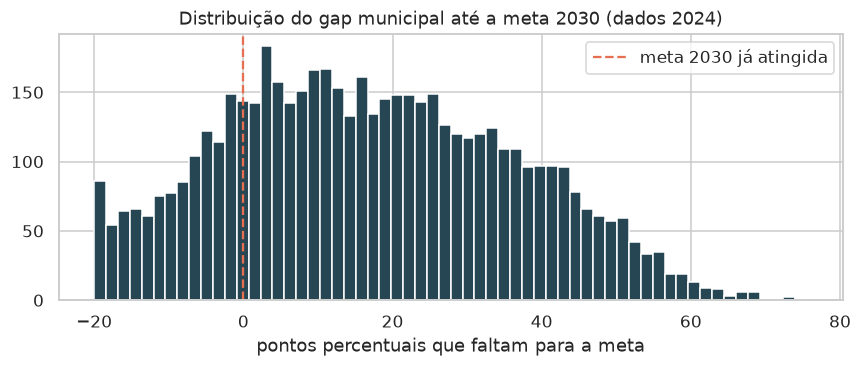

Municípios que já atingiram a meta 2030: 21.3%


In [10]:
evo = pd.read_parquet("../data/gold_evolucao_temporal.parquet")
metas = pd.read_parquet("../data/gold_metas_x_resultados.parquet")
print(evo.columns.tolist())
print(metas.columns.tolist())
gap = metas.query("nivel == 'municipio' and ano == 2024")["gap_para_meta_2030"].dropna()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(gap, bins=60, color="#264653")
ax.axvline(0, color="#e76f51", ls="--", label="meta 2030 já atingida")
ax.set_title("Distribuição do gap municipal até a meta 2030 (dados 2024)")
ax.set_xlabel("pontos percentuais que faltam para a meta")
ax.legend()
plt.tight_layout()
plt.savefig(IMG / "eda_gap_metas.png", bbox_inches="tight")
plt.show()
print(f"Municípios que já atingiram a meta 2030: {(gap <= 0).mean():.1%}")

## 7. Hipóteses analíticas (sustentam o notebook 02)

Com base no que os dados mostraram:

- **H1. Histórico educacional municipal é o preditor mais forte.** O IDEB/nota
  Saeb dos anos iniciais na edição anterior tem a maior correlação com o desfecho.
- **H2. Nível socioeconômico importa, com os dois sinais.** IDHM, renda e
  escolaridade adulta elevam a probabilidade de alfabetização; pobreza infantil e
  analfabetismo adulto a reduzem.
- **H3. Entre as redes públicas há diferença relevante.** A avaliação cobre
  essencialmente municipal × estadual (privada é residual na base, 24 alunos);
  a diferença entre as duas redes públicas é real, mas menor que o efeito
  territorial e socioeconômico.
- **H4. O gradiente territorial é forte** (Norte/Nordeste × Sul/Sudeste) e parte
  dele deve ser explicada pelas variáveis socioeconômicas; o modelo dirá quanto.
- **H5. Infraestrutura escolar contribui de forma moderada** (internet,
  biblioteca, saneamento), possivelmente como proxy de condições gerais da rede.

**Decisões de modelagem derivadas:**
1. Problema de **classificação binária** com classes razoavelmente balanceadas
   → sem reamostragem; usar métricas sensíveis às duas classes (ROC-AUC, F1).
2. Features numéricas com caudas longas (população, PIB pc, renda) → modelos de
   árvore são robustos a escala; para o modelo linear, imputação + padronização.
3. **Validação temporal** (treinar em 2023, testar em 2024) reflete o uso real.
4. **Split por grupo** (escola/município) nas validações aleatórias, para não
   decorar territórios.
5. Interpretabilidade obrigatória (SHAP) para transformar correlação em fatores
   acionáveis por gestores.